# Competitor Comparison

The purpose of this notebook is to compare the Robust Mixed Effects (RoME) algorithm to various competing algorithms.
This notebook contains three separate simulations that compare these methods.

In the first simulation, the standard Thompson sampling assumptions hold,
and the users are assumed to be homogeneous in the sense that their advantage functions (causal effects) are the same.

The second situation is similar, but users are heterogeneous in the sense that they have different advantage functions.

In the third simulation, the data-generating mechanism is much more complex.
In addition to being nonlinear, it also includes effects for users and time.
Consequently, only the RoME method performs well in this setting.

# Shared Setup

In [1]:
# Generic imports
import pandas as pd
import numpy as np
import scipy
import scipy.sparse
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import seaborn as sns
from river import linear_model
import copy
from multiprocessing import cpu_count
from joblib import Parallel, delayed
import pickle
import tensorflow as tf
import keras
from keras import layers, regularizers
import time

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 50)

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-k73qyj4y because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
2025-01-11 13:29:43.310730: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Imports from this project
from models.models import OracleTS, StandardTS, ActionCenteredTS, RoME, IntelligentPooling, UserLaplacian
from models.river_wrapper import RiverBatchEstimator
from models.bagging_mod import BaggingRegressor
from models.utils import find_neighbors
from simulations.data_generator import DataGenerator

In [3]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab10.colors)
plt.rcParams['font.family'] = 'sans-serif'

In [4]:
# Simulation setup: try some different values
N_STAGES = 200
N_OBSERVATIONS = N_STAGES * (N_STAGES + 1) // 2
N = N_STAGES
T = N_STAGES
THETA = np.array([1., 0.5, -4.])
CONTEXT_DIM = 2
EXTRA_CONTEXT_DIM = 2
LINEAR_BASELINE_COEF = np.array([2., -2., 3.])
THETA_TIME_INIT = np.array([-2., -4., 6.])
P = THETA.size
n_jobs = 25
REPS = 50
N_NEIGHBORS = 5

In [5]:
def get_max_norm(x):
    squared_norms = (x**2).sum(axis=1)
    norms = np.sqrt(squared_norms)
    max_norm = np.max(norms)
    return max_norm

def get_max_norm_for_pairs(x, pairs):
    x_diffs = x[pairs[0]] - x[pairs[1]]
    max_norm = get_max_norm(x_diffs)
    return max_norm

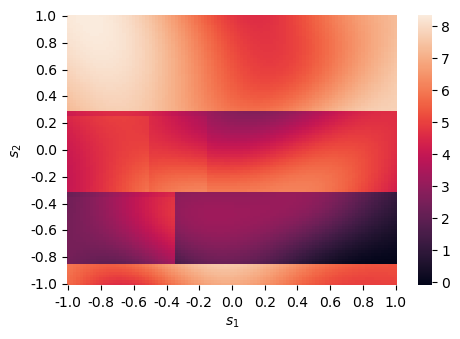

In [6]:
homogeneous_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="homogeneous", linear_baseline_coef=LINEAR_BASELINE_COEF, random_seed=1)
homogeneous_data_generator = homogeneous_data_generator.sample_theta(theta_base=THETA)

heterogeneous_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="heterogeneous", linear_baseline_coef=LINEAR_BASELINE_COEF, random_seed=1)
heterogeneous_data_generator = heterogeneous_data_generator.sample_theta(theta_base=THETA)

nonlinear_data_generator = DataGenerator(stage_max=N_STAGES, assumptions="nonlinear", random_seed=3, nonlinear_scale=1.)  # Seed chosen for its interesting nonlinear relationships
nonlinear_data_generator = nonlinear_data_generator.sample_theta(theta_base=THETA, theta_time_init=THETA_TIME_INIT)

# Baseline Reward
num_vals = 101
s1_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s2_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s1_vals_repped, s2_vals_repped = np.meshgrid(s1_vals, s2_vals)
context_values = np.vstack([s1_vals_repped.flatten(), s2_vals_repped.flatten()]).T
baseline_vals = nonlinear_data_generator._nonlinear_baseline_function(context_values, scale=nonlinear_data_generator.nonlinear_scale)
heatmap_min = np.min(baseline_vals)
heatmap_max = np.max(baseline_vals)

baseline_vals_df = pd.DataFrame(
    data=baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax = sns.heatmap(baseline_vals_df, xticklabels=10, yticklabels=10, ax=ax)
plt.xlabel("$s_{1}$")
plt.ylabel("$s_{2}$")
# plt.title("Baseline Reward as a Function of State")
fig.tight_layout()
fig.savefig("figures/baseline_reward.png")
fig.savefig("figures/baseline_reward.pdf")
plt.show()

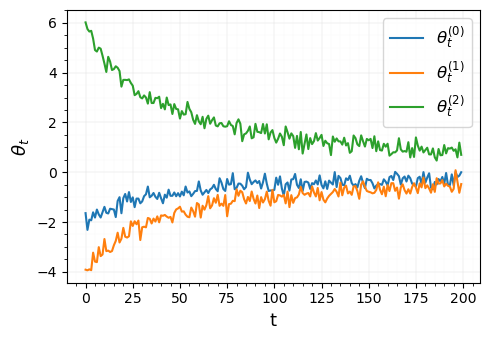

In [7]:
# Time-specifc thetas
fig, ax = plt.subplots(figsize=(5, 3.5))
for i in range(THETA.size):
    label = "$\\theta^{(idx)}_{t}$".replace("idx", str(i))
    ax.plot(nonlinear_data_generator.theta_time[:, i], alpha=1, label=label)
ax.grid(which='major', color='#DDDDDD', linewidth=0.3)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.3)
ax.minorticks_on()
ax.set_xlabel("t", fontsize=13)
ax.set_ylabel("$\\theta_{t}$", fontsize=13)
# plt.title("Values of $\\theta_{time}$ Plotted Over Time")
ax.legend(fontsize=12)
fig.tight_layout()
fig.savefig("figures/theta_time.png")
fig.savefig("figures/theta_time.pdf")
plt.show()

Epoch 1/20


2025-01-11 13:29:48.529605: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


200/200 [==============================] - 1s 2ms/step - loss: 1.5142 - val_loss: 1.0951
Epoch 2/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0660 - val_loss: 1.0610
Epoch 3/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0547 - val_loss: 1.0543
Epoch 4/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0438 - val_loss: 1.0483
Epoch 5/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0386 - val_loss: 1.0698
Epoch 6/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0382 - val_loss: 1.0857
Epoch 7/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0394 - val_loss: 1.0551
Epoch 8/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0320 - val_loss: 1.0373
Epoch 9/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0273 - val_loss: 1.0548
Epoch 10/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0272 - val_loss: 1.0917
Epoch 11/2

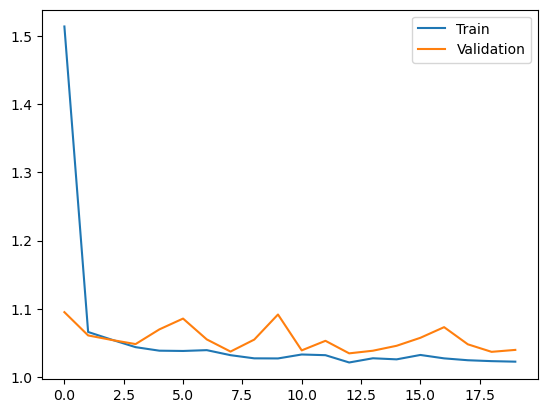

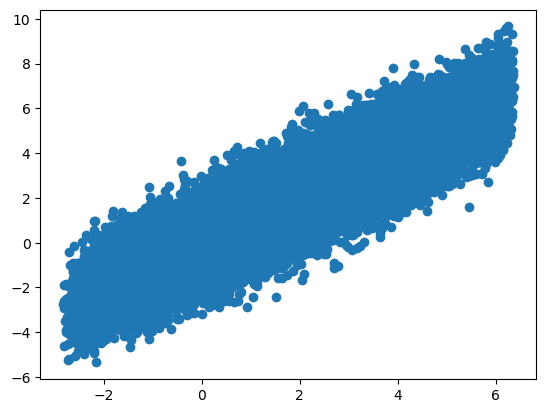

INFO:tensorflow:Assets written to: tri-homogeneous-nn/assets


INFO:tensorflow:Assets written to: tri-homogeneous-nn/assets


Epoch 1/20
200/200 [==============================] - 1s 2ms/step - loss: 1.4285 - val_loss: 1.1231
Epoch 2/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0798 - val_loss: 1.0774
Epoch 3/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0692 - val_loss: 1.0624
Epoch 4/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0590 - val_loss: 1.0517
Epoch 5/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0530 - val_loss: 1.0460
Epoch 6/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0488 - val_loss: 1.0518
Epoch 7/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0504 - val_loss: 1.0674
Epoch 8/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0405 - val_loss: 1.0419
Epoch 9/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0408 - val_loss: 1.0560
Epoch 10/20
200/200 [==============================] - 0s 1ms/step - loss: 1.0427 - val_loss: 1.0459

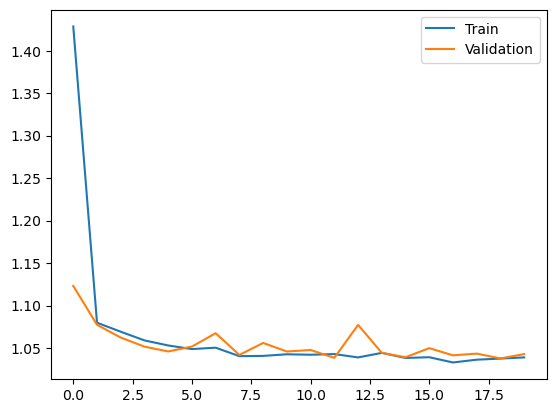

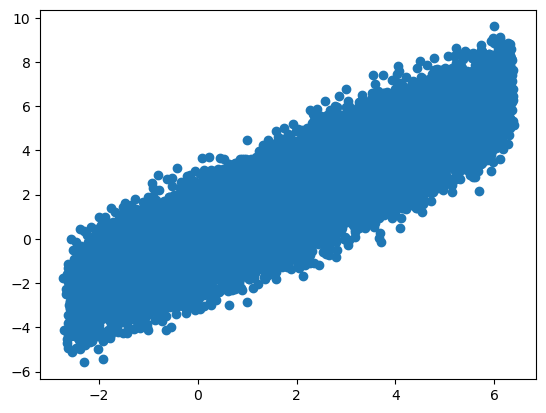

INFO:tensorflow:Assets written to: tri-heterogeneous-nn/assets


INFO:tensorflow:Assets written to: tri-heterogeneous-nn/assets


Epoch 1/50
200/200 [==============================] - 1s 2ms/step - loss: 3.7532 - val_loss: 2.3765
Epoch 2/50
200/200 [==============================] - 0s 1ms/step - loss: 2.0747 - val_loss: 1.8650
Epoch 3/50
200/200 [==============================] - 0s 1ms/step - loss: 1.6591 - val_loss: 1.5545
Epoch 4/50
200/200 [==============================] - 0s 1ms/step - loss: 1.5696 - val_loss: 1.5661
Epoch 5/50
200/200 [==============================] - 0s 1ms/step - loss: 1.5160 - val_loss: 1.5181
Epoch 6/50
200/200 [==============================] - 0s 1ms/step - loss: 1.5079 - val_loss: 1.4663
Epoch 7/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4586 - val_loss: 1.4521
Epoch 8/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4389 - val_loss: 1.4138
Epoch 9/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4129 - val_loss: 1.4403
Epoch 10/50
200/200 [==============================] - 0s 1ms/step - loss: 1.4153 - val_loss: 1.3877

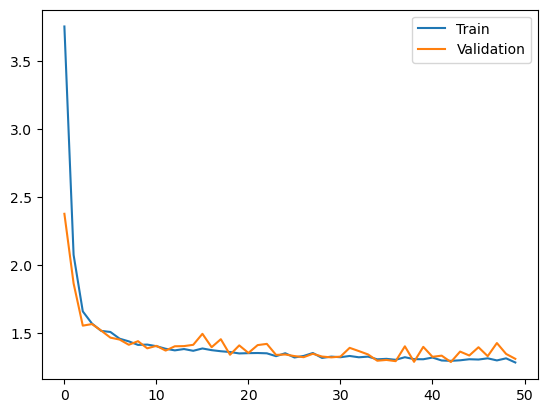

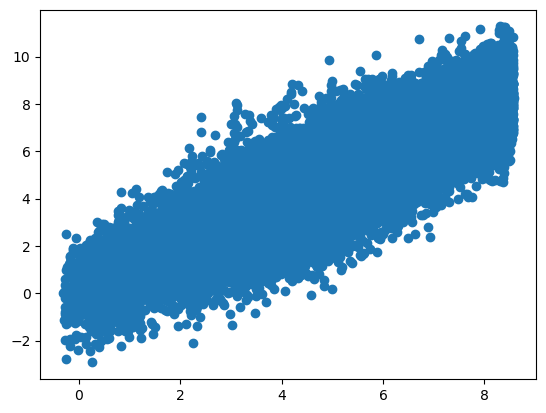

INFO:tensorflow:Assets written to: tri-nonlinear-nn/assets


INFO:tensorflow:Assets written to: tri-nonlinear-nn/assets


In [8]:
# Neural network stuff
nn_input_dim = CONTEXT_DIM + EXTRA_CONTEXT_DIM

data_generators = [homogeneous_data_generator, heterogeneous_data_generator, nonlinear_data_generator]
model_files = ["tri-homogeneous-nn", "tri-heterogeneous-nn", "tri-nonlinear-nn"]
for i, (data_generator, model_file) in enumerate(zip(data_generators, model_files)):
    # Create data
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)
    X_train, y_train = data_generator.generate_baselines_for_nn()
    
    data_generator = data_generator.reset()
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)
    X_validation, y_validation = data_generator.generate_baselines_for_nn()
    
    # Train model
    penalty = 0.001
    nn_output_dim = 10
    model = keras.Sequential(
        [
            keras.Input(shape=(nn_input_dim,), name="input"),
            layers.Dense(10, activation="relu", name="layer1", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(20, activation="relu", name="layer2", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(20, activation="tanh", name="layer3", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(nn_output_dim, activation="tanh", name="layer4", kernel_regularizer=regularizers.l2(penalty)),
            layers.Dense(1, name="output", kernel_regularizer=regularizers.l2(penalty)),
        ]
    )
    opt = keras.optimizers.Adam(learning_rate=0.01)
    model.compile(loss="mse", optimizer=opt)
    history = model.fit(
        X_train,
        y_train,
        batch_size=200,
        validation_data=(X_validation, y_validation),
        epochs=50 if i == 2 else 20,
        # epochs=1,
        verbose=1
    )
    
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Validation")
    plt.legend()
    plt.show()

    preds_validation = model(X_validation)
    plt.scatter(preds_validation, y_validation)
    plt.show()
    
    # Featurizer model
    featurizer_nn_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer("layer4").output)
    featurizer_nn_model.compile()
    featurizer_nn_model.save(model_file)

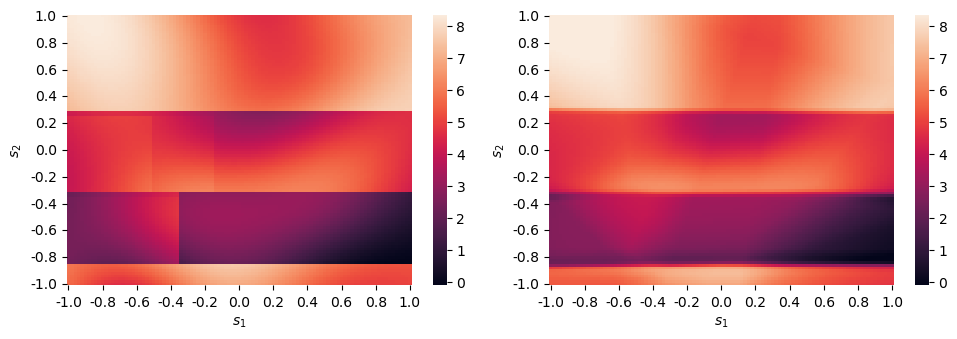

In [9]:
# Baseline Reward
num_vals = 101
s1_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s2_vals = np.round(np.linspace(-1., 1., num=num_vals), 2)
s1_vals_repped, s2_vals_repped = np.meshgrid(s1_vals, s2_vals)
context_values = np.vstack([s1_vals_repped.flatten(), s2_vals_repped.flatten()]).T
baseline_vals = nonlinear_data_generator._nonlinear_baseline_function(context_values, scale=nonlinear_data_generator.nonlinear_scale)

baseline_vals_df = pd.DataFrame(
    data=baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
sns.heatmap(baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax[0])
ax[0].set_xlabel("$s_{1}$")
ax[0].set_ylabel("$s_{2}$")

nn_context_values = np.hstack([context_values, np.zeros_like(context_values)])
nn_baseline_vals = model(nn_context_values).numpy()
nn_baseline_vals_df = pd.DataFrame(
    data=nn_baseline_vals.reshape((num_vals, num_vals)),
    index=s1_vals,
    columns=s2_vals).sort_index(ascending=False)

sns.heatmap(nn_baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax[1])
ax[1].set_xlabel("$s_{1}$")
ax[1].set_ylabel("$s_{2}$")

fig.tight_layout()
fig.savefig("figures/nn_baseline_reward_comparison.png")
fig.savefig("figures/nn_baseline_reward_comparison.pdf")
plt.show()

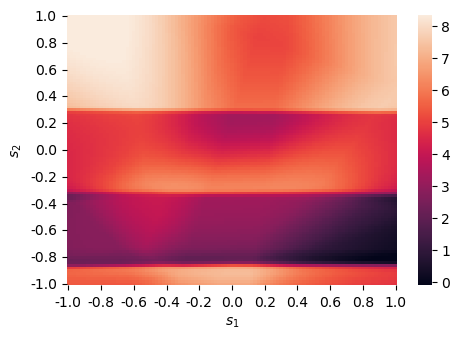

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax = sns.heatmap(nn_baseline_vals_df, vmin=heatmap_min, vmax=heatmap_max, xticklabels=10, yticklabels=10, ax=ax)
plt.xlabel("$s_{1}$")
plt.ylabel("$s_{2}$")
# plt.title("Baseline Reward as a Function of State")
fig.tight_layout()
fig.savefig("figures/nn_baseline_reward.png")
fig.savefig("figures/nn_baseline_reward.pdf")
plt.show()

In [11]:
# This determines the plotting order
non_oracle_method_names = [
    "IntelPooling",
    "RoME-BLM",
    "RoME",
    "RoME-SU",
    "AC",
    "Standard",
    "Neural-Linear",
    "NNR-Linear"
]

def create_reward_dict(data_generator, nn_model_name, seed):
    np.random.seed(seed)
    user_pairs, L_user = find_neighbors(
        data_generator.theta_user + 0.1*np.random.normal(size=data_generator.theta_user.shape),
        N_NEIGHBORS)
    time_pairs, L_time = find_neighbors(
        data_generator.theta_time + 1.*np.random.normal(size=data_generator.theta_user.shape),
        N_NEIGHBORS)
    
    bagged_lm = RiverBatchEstimator(
        BaggingRegressor(
            linear_model.LinearRegression(l2=1e-8, intercept_lr=0.1),
            n_models=10,
            subsample=0.8
        )
    )

    # Set covariances
    cov_epsilon = 1e-18
    user_cov = np.cov(data_generator.theta_user.T)
    if user_cov.sum() < cov_epsilon:
        user_cov += cov_epsilon * np.eye(user_cov.shape[0])
    time_cov = np.cov(data_generator.theta_time.T)
    if time_cov.sum() < cov_epsilon:
        time_cov += cov_epsilon * np.eye(time_cov.shape[0])

    nn = tf.keras.models.load_model(nn_model_name)
    nn_numpy = lambda x: nn(x).numpy()
    
    non_oracle_methods_dict = {
        "IntelPooling": IntelligentPooling(N, T, P, DataGenerator._featurize, user_cov=user_cov, time_cov=time_cov),
        "RoME": RoME(N, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, n_neighbors=N_NEIGHBORS),
        "RoME-BLM": RoME(N, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, ml_interactions=True, ml_model=bagged_lm, n_neighbors=N_NEIGHBORS),
        "RoME-SU": RoME(1, T, P, DataGenerator._featurize, L_user, L_time, user_cov=user_cov, time_cov=time_cov, n_neighbors=N_NEIGHBORS, pool_users=False),
        "AC": ActionCenteredTS(N, T, P, DataGenerator._featurize),
        "Standard": StandardTS(N, T, P, DataGenerator._featurize),
        "Neural-Linear": StandardTS(N, T, P, DataGenerator._featurize, nn=nn_numpy, nn_dim=nn_output_dim),
        "NNR-Linear": UserLaplacian(N, T, P, DataGenerator._featurize, L_user, user_cov=user_cov),
    }
    methods_dict = copy.copy(non_oracle_methods_dict)
    methods_dict["Oracle"] = OracleTS(N, T, THETA, data_generator.theta_user, data_generator.theta_time, DataGenerator._featurize)
    
    # Dictionary for storing rewards
    rewards_dict = {k:np.zeros((N, T)) for k in methods_dict}
    timings_dict = {}

    # Generate context vectors that we'll use for all models
    data_generator = data_generator.generate_all_contexts(context_dim=CONTEXT_DIM, extra_context_dim=EXTRA_CONTEXT_DIM)

    # Iterate through methods
    for method_name, method in methods_dict.items():
        rewards = []
        data_generator = data_generator.reset()
        method.reset()
        method_start_time = time.time()

        while not data_generator.finished:
            # Randomly samples action from current policy
            context, context_extra, user_idx, time_idx = data_generator.get_current_context()
            action = method.sample_action(context, user_idx, time_idx)

            # Plays action and returns reward
            reward = data_generator.play_action(action)
            rewards_dict[method_name][user_idx, time_idx] = reward

            # Update method inferences
            method.update(context, context_extra, user_idx, time_idx, action, reward)
        method_end_time = time.time()
        method_elapsed_time = method_end_time - method_start_time
        timings_dict[method_name] = method_elapsed_time

    return rewards_dict, timings_dict

In [12]:
def run_simulation(data_generator, nn_model_name, REPS=REPS, n_jobs=cpu_count()):    
    # Perform whole simulation REPS times
    pool_args = zip(
        [copy.deepcopy(data_generator) for _ in range(REPS)],
        [nn_model_name]*REPS,
        range(REPS))
    print("Starting parallel")
    list_of_tuples_of_dicts = Parallel(n_jobs=n_jobs)(delayed(create_reward_dict)(*arg) for arg in pool_args)    
    print("Parallel closed")
    rewards_list_of_dicts = [t[0] for t in list_of_tuples_of_dicts]
    timings_list_of_dicts = [t[1] for t in list_of_tuples_of_dicts]
    rewards_dict = {}
    timings_dict = {}
    method_names = list(rewards_list_of_dicts[0].keys())
    non_oracle_method_names = list(set(method_names) - set(["Oracle"]))
    for method_name in method_names:
        rewards_dict[method_name] = np.asarray([
            rewards_list_of_dicts[i][method_name]
            for i in range(REPS)])
        timings_dict[method_name] = np.asarray([
            timings_list_of_dicts[i][method_name]
            for i in range(REPS)])
                
    return rewards_dict, timings_dict

In [13]:
def get_avg_stage_reward(a):
    means = [a[:, ::-1].diagonal(i, axis1=1, axis2=2).mean(axis=1) for i in range(-a.shape[1]+1,a.shape[2])]
    return np.asarray(means)[:a.shape[1]]


def plot_rewards_dict(rewards_dict, assumptions):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax0 = ax[0]
    ax1 = ax[1]
    
    # Calculate incremental regret
    oracle_incremental_regret = get_avg_stage_reward(rewards_dict["Oracle"])
    incremental_regret_dict = {
        method_name: (oracle_incremental_regret - get_avg_stage_reward(rewards_dict[method_name])).mean(axis=1)  # Mean over reps
        for method_name in non_oracle_method_names}

    # Calculate cumulative regret
    cumulative_regret_dict = {method_name: np.cumsum(incremental_regret_dict[method_name]) for method_name in non_oracle_method_names}

    # Plot incremental regret
    for method_name in non_oracle_method_names:
        ax0.plot(incremental_regret_dict[method_name], label=method_name, )
    ax0.set_title("(a) Incremental Regret Over Time", pad=10)
    ax0.set_ylabel("Incremental Regret")
    ax0.set_xlabel("Stage")
    ax0.legend()

    # Plot cumulative regret
    for method_name in non_oracle_method_names:
        ax1.plot(cumulative_regret_dict[method_name], label=method_name)
    ax1.set_title("(b) Cumulative Regret Over Time", pad=10)
    ax1.set_ylabel("Cumulative Regret")
    ax1.set_xlabel("Stage")
    plt.legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    fig.savefig(f"figures/{assumptions}-regret.png")
    fig.savefig(f"figures/{assumptions}-regret.pdf")
    fig.suptitle(f"Regret for {assumptions.capitalize()} Data-Generating Process")
    plt.show()

# Simulation 1: Homogeneous Users, Linear Baseline, No Time Effects

In [14]:
homogeneous_rewards_dict, homogeneous_timings_dict = run_simulation(homogeneous_data_generator, model_files[0], n_jobs=n_jobs)

Starting parallel


2025-01-11 13:30:21.960601: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 13:30:21.960600: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 13:30:21.966624: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [15]:
def print_timings(timings_dict_):
    print("Average elapsed time by method")
    for k in timings_dict_:
        mean_timing = timings_dict_[k].mean()
        print(f"{k}: {mean_timing}")
    timings_df = pd.DataFrame(timings_dict_)
    print(timings_df)
    return timings_df
print_timings(homogeneous_timings_dict)

Average elapsed time by method
IntelPooling: 46.6141960811615
RoME: 394.4933143043518
RoME-BLM: 94.57744940280914
RoME-SU: 383.53077624320986
AC: 0.11729949474334717
Standard: 0.15987775802612306
Neural-Linear: 0.7220542335510254
NNR-Linear: 29.7038871383667
Oracle: 0.019280447959899902
    IntelPooling        RoME   RoME-BLM     RoME-SU        AC  Standard  \
0      48.291575  370.801564  95.954082  374.164791  0.113995  0.158394   
1      46.146516  377.381409  95.384902  371.888146  0.114840  0.158821   
2      48.127676  366.622038  96.879356  366.552531  0.114696  0.159621   
3      45.950751  368.912273  91.063527  368.699153  0.115088  0.159161   
4      47.424869  361.723370  96.181074  362.654773  0.114627  0.160162   
5      48.954731  370.518478  94.477525  363.969220  0.116660  0.159355   
6      46.915029  368.141547  96.166179  366.202905  0.114873  0.159306   
7      48.442284  364.337658  95.523093  361.067580  0.116952  0.159729   
8      48.684599  365.729938  95.4932

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,48.291575,370.801564,95.954082,374.164791,0.113995,0.158394,0.738347,29.880299,0.019773
1,46.146516,377.381409,95.384902,371.888146,0.114840,0.158821,0.729027,29.285344,0.018994
2,48.127676,366.622038,96.879356,366.552531,0.114696,0.159621,0.746486,29.499056,0.019331
3,45.950751,368.912273,91.063527,368.699153,0.115088,0.159161,0.732799,28.937709,0.019233
4,47.424869,361.723370,96.181074,362.654773,0.114627,0.160162,0.736115,29.700125,0.019220
5,48.954731,370.518478,94.477525,363.969220,0.116660,0.159355,0.740879,29.000295,0.018723
6,46.915029,368.141547,96.166179,366.202905,0.114873,0.159306,0.736971,29.635090,0.018600
7,48.442284,364.337658,95.523093,361.067580,0.116952,0.159729,0.738729,29.293739,0.018761
8,48.684599,365.729938,95.493208,360.301694,0.114835,0.159037,0.764371,28.913597,0.019384
9,47.269405,372.364148,97.257785,362.814201,0.114831,0.159897,0.747385,29.971016,0.018885


In [16]:
homogeneous_rewards_filename = "checkpoints/homogeneous_rewards.pkl"
with open(homogeneous_rewards_filename, 'wb') as file:
    pickle.dump(homogeneous_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [17]:
with open(homogeneous_rewards_filename, "rb") as file:
    homogeneous_rewards_dict = pickle.load(file)

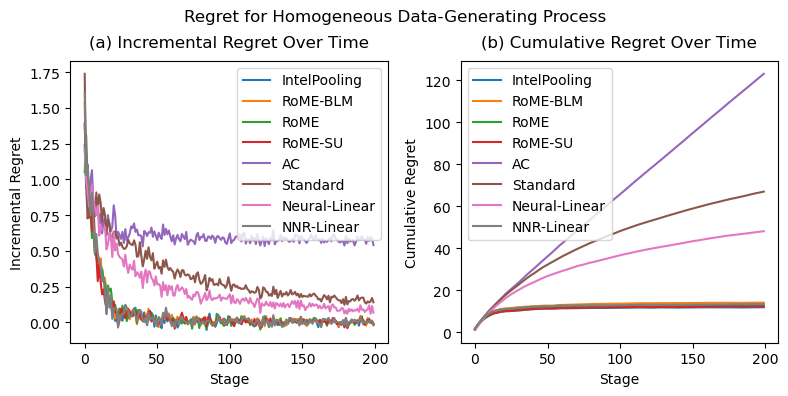

In [18]:
plot_rewards_dict(homogeneous_rewards_dict, "homogeneous")

# Simulation 2: Heterogeneous Users, Linear Baseline, No Time Effects

In [19]:
heterogeneous_rewards_dict, heterogeneous_timings_dict = run_simulation(heterogeneous_data_generator, model_files[1], n_jobs=n_jobs)

Starting parallel


2025-01-11 14:05:18.437368: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 14:05:18.457457: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 14:05:18.458819: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [20]:
print_timings(heterogeneous_timings_dict)

Average elapsed time by method
IntelPooling: 42.05319900035858
RoME: 406.3552170562744
RoME-BLM: 96.83374711990356
RoME-SU: 390.46188324928283
AC: 0.11597397327423095
Standard: 0.16063403129577636
Neural-Linear: 0.7557319355010986
NNR-Linear: 31.326233830451965
Oracle: 0.01937758445739746
    IntelPooling        RoME    RoME-BLM     RoME-SU        AC  Standard  \
0      41.051704  367.919677  100.354791  373.150033  0.116789  0.160962   
1      40.847236  370.551907   97.741896  373.047425  0.116421  0.160122   
2      41.159135  363.862872  100.039305  379.624052  0.115123  0.160728   
3      41.293887  380.169738  100.845265  386.971821  0.116501  0.160331   
4      44.068322  375.314292   98.433115  375.275675  0.122936  0.168764   
5      41.382244  364.833038   97.382881  376.652852  0.115132  0.159063   
6      41.839707  375.610727   98.010481  385.702845  0.115527  0.159332   
7      39.799869  359.198553   99.770374  368.453588  0.114213  0.160712   
8      40.341336  377.9148

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,41.051704,367.919677,100.354791,373.150033,0.116789,0.160962,0.794510,31.279504,0.019716
1,40.847236,370.551907,97.741896,373.047425,0.116421,0.160122,0.824384,31.671604,0.019888
2,41.159135,363.862872,100.039305,379.624052,0.115123,0.160728,0.823112,31.307322,0.018788
3,41.293887,380.169738,100.845265,386.971821,0.116501,0.160331,0.790199,30.920133,0.018796
4,44.068322,375.314292,98.433115,375.275675,0.122936,0.168764,0.830304,31.905451,0.019832
5,41.382244,364.833038,97.382881,376.652852,0.115132,0.159063,0.797220,30.673983,0.019429
6,41.839707,375.610727,98.010481,385.702845,0.115527,0.159332,0.828249,31.538059,0.018644
7,39.799869,359.198553,99.770374,368.453588,0.114213,0.160712,0.800785,30.940092,0.018671
8,40.341336,377.914850,96.538672,382.325849,0.118744,0.164010,0.848283,30.813348,0.019457
9,41.471293,377.499753,98.645809,380.590777,0.118006,0.161195,0.764272,31.953195,0.020257


In [21]:
heterogeneous_rewards_filename = "checkpoints/heterogeneous_rewards.pkl"
with open(heterogeneous_rewards_filename, 'wb') as file:
    pickle.dump(heterogeneous_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [22]:
with open(heterogeneous_rewards_filename, "rb") as file:
    heterogeneous_rewards_dict = pickle.load(file)

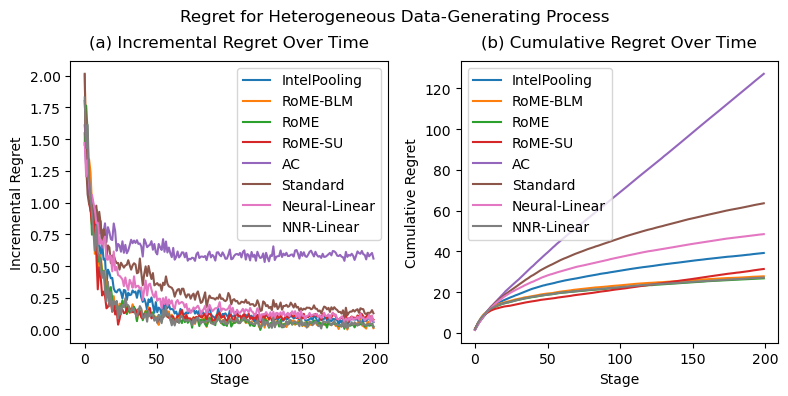

In [23]:
plot_rewards_dict(heterogeneous_rewards_dict, "heterogeneous")

# Simulation 3: Nonlinear Baseline and User-/Time-specific Effects

In [24]:
nonlinear_rewards_dict, nonlinear_timings_dict = run_simulation(nonlinear_data_generator, model_files[2], n_jobs=n_jobs)

Starting parallel


2025-01-11 14:47:55.448053: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 14:47:55.940234: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-11 14:47:55.945708: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 

Parallel closed


In [25]:
print_timings(nonlinear_timings_dict)

Average elapsed time by method
IntelPooling: 44.93998699188232
RoME: 420.08037355899813
RoME-BLM: 109.91578743457794
RoME-SU: 396.4598818874359
AC: 0.25762436389923093
Standard: 0.3021473550796509
Neural-Linear: 0.8874310731887818
NNR-Linear: 31.450948672294615
Oracle: 0.15785111904144286
    IntelPooling        RoME    RoME-BLM     RoME-SU        AC  Standard  \
0      45.749181  391.533558  107.967017  370.630695  0.257642  0.300164   
1      46.138700  400.775779  107.571871  381.995238  0.255031  0.298054   
2      46.222082  404.258894  107.812269  382.537091  0.252679  0.296040   
3      45.537889  387.587607  107.127643  366.889178  0.249946  0.295745   
4      47.860646  381.856797  107.353360  362.092092  0.267351  0.313212   
5      46.055977  399.079937  109.100692  378.272311  0.256141  0.298889   
6      46.272514  396.592128  112.015425  385.050359  0.252319  0.295900   
7      45.711460  391.652982  113.619193  375.821883  0.252969  0.295704   
8      45.870069  390.8642

,IntelPooling,RoME,RoME-BLM,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear,Oracle
0,45.749181,391.533558,107.967017,370.630695,0.257642,0.300164,0.893881,31.267678,0.155609
1,46.138700,400.775779,107.571871,381.995238,0.255031,0.298054,0.884048,31.499202,0.154078
2,46.222082,404.258894,107.812269,382.537091,0.252679,0.296040,1.002456,31.348036,0.250678
3,45.537889,387.587607,107.127643,366.889178,0.249946,0.295745,0.881655,31.551435,0.163474
4,47.860646,381.856797,107.353360,362.092092,0.267351,0.313212,0.908038,31.914074,0.163722
5,46.055977,399.079937,109.100692,378.272311,0.256141,0.298889,0.914447,31.739746,0.153124
6,46.272514,396.592128,112.015425,385.050359,0.252319,0.295900,0.882177,31.238062,0.151418
7,45.711460,391.652982,113.619193,375.821883,0.252969,0.295704,0.942570,31.185496,0.152375
8,45.870069,390.864233,111.498972,375.721038,0.254118,0.297451,0.918913,30.709422,0.151014
9,46.494189,394.592250,113.366975,381.921754,0.254111,0.302461,0.910136,31.203228,0.150716


In [26]:
nonlinear_rewards_filename = "checkpoints/nonlinear_rewards.pkl"
with open(nonlinear_rewards_filename, 'wb') as file:
    pickle.dump(nonlinear_rewards_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [27]:
with open(nonlinear_rewards_filename, "rb") as file:
    nonlinear_rewards_dict = pickle.load(file)

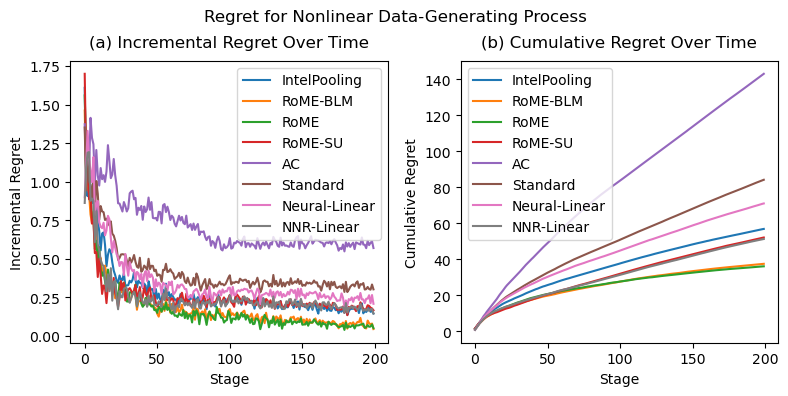

In [28]:
plot_rewards_dict(nonlinear_rewards_dict, "nonlinear")

# Cumulative Regret for All Three Settings

## Calculations

In [29]:
# Calculate incremental regret
incremental_homogeneous_regret_dict = {
    method_name: get_avg_stage_reward(homogeneous_rewards_dict["Oracle"]) - get_avg_stage_reward(homogeneous_rewards_dict[method_name])
    for method_name in non_oracle_method_names}
incremental_heterogeneous_regret_dict = {
    method_name: get_avg_stage_reward(heterogeneous_rewards_dict["Oracle"]) - get_avg_stage_reward(heterogeneous_rewards_dict[method_name])
    for method_name in non_oracle_method_names}
incremental_nonlinear_regret_dict = {
    method_name: get_avg_stage_reward(nonlinear_rewards_dict["Oracle"]) - get_avg_stage_reward(nonlinear_rewards_dict[method_name])
    for method_name in non_oracle_method_names}

# Calculate cumulative regret
cumulative_homogeneous_regret_dict = {method_name: np.cumsum(incremental_homogeneous_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}
cumulative_heterogeneous_regret_dict = {method_name: np.cumsum(incremental_heterogeneous_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}
cumulative_nonlinear_regret_dict = {method_name: np.cumsum(incremental_nonlinear_regret_dict[method_name], axis=0) for method_name in non_oracle_method_names}

# Final regret
final_homogeneous_regret_df = pd.DataFrame({
    method_name: cumulative_homogeneous_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_homogeneous_regret_df.to_csv("./checkpoints/final_homogeneous_regret.csv", index=False)

final_heterogeneous_regret_df = pd.DataFrame({
    method_name: cumulative_heterogeneous_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_heterogeneous_regret_df.to_csv("./checkpoints/final_heterogeneous_regret.csv", index=False)

final_nonlinear_regret_df = pd.DataFrame({
    method_name: cumulative_nonlinear_regret_dict[method_name][-1]
    for method_name in non_oracle_method_names})
final_nonlinear_regret_df.to_csv("./checkpoints/final_nonlinear_regret.csv", index=False)

## Plots

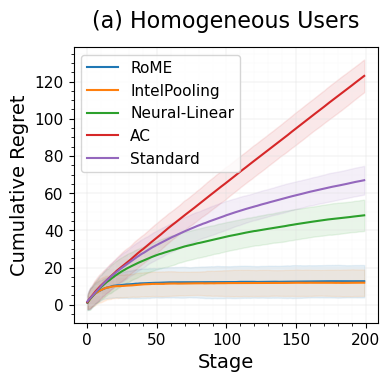

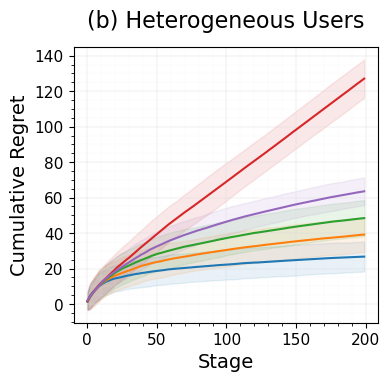

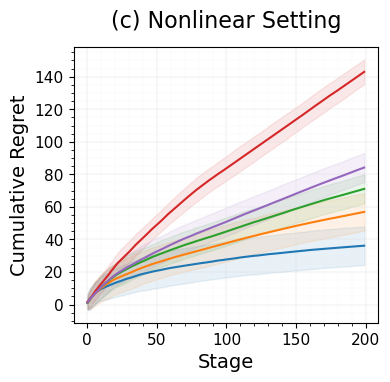

In [30]:
def plot_cumulative_regret(cumulative_regret_dict, setting_name, include_legend=False, loc="main", include_bands=True):
    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    for i, method_name in enumerate(cumulative_regret_dict.keys()):
        color_i = f"C{i}"
        method_means = cumulative_regret_dict[method_name].mean(axis=1)
        method_range = np.arange(method_means.size)
        method_sds = cumulative_regret_dict[method_name].std(axis=1)
        method_lower = method_means - 1.96 * method_sds
        method_upper = method_means + 1.96 * method_sds
        if include_bands:
            ax.fill_between(method_range, method_lower, method_upper, color=color_i, alpha=0.1)
        ax.plot(method_range, method_means, label=method_name, color=color_i)
        
    ax.grid(which='major', color='#DDDDDD', linewidth=0.3)
    ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.3)
    ax.minorticks_on()
    ax.set_title(setting_name, pad=14, fontsize=16)
    ax.set_ylabel("Cumulative Regret", fontsize=14)
    ax.set_xlabel("Stage", fontsize=14)
    ax.tick_params(axis='both', labelsize=11)
    if include_legend:
        ax.legend(fontsize=11)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    setting_name_for_file = setting_name.replace("(", "").replace(")", "").replace(" ", "-")
    fig.savefig(f"figures/cumulative-regret-{setting_name_for_file}-{loc}.png")
    fig.savefig(f"figures/cumulative-regret-{setting_name_for_file}-{loc}.pdf")
    # fig.suptitle("Comparison of Cumulative Regret by Method")
    plt.show()

main_paper_methods = ["RoME", "IntelPooling", "Neural-Linear", "AC", "Standard"]

plot_cumulative_regret(
    {m:cumulative_homogeneous_regret_dict[m] for m in main_paper_methods},
    setting_name="(a) Homogeneous Users", include_legend=True)

plot_cumulative_regret(
    {m:cumulative_heterogeneous_regret_dict[m] for m in main_paper_methods},
    setting_name="(b) Heterogeneous Users", include_legend=False)

plot_cumulative_regret(
    {m:cumulative_nonlinear_regret_dict[m] for m in main_paper_methods},
    setting_name="(c) Nonlinear Setting", include_legend=False)

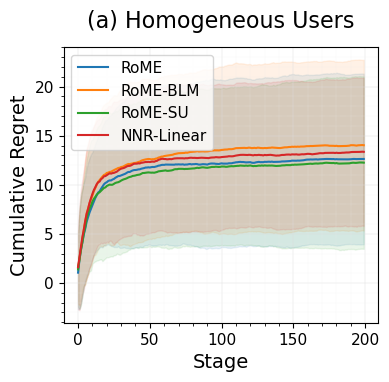

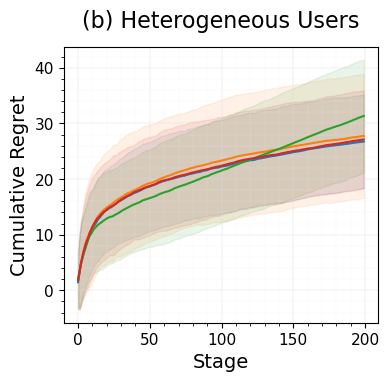

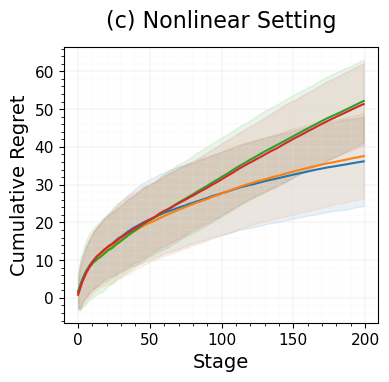

In [31]:
appendix_methods = ["RoME", "RoME-BLM", "RoME-SU", "NNR-Linear"]

plot_cumulative_regret(
    {m:cumulative_homogeneous_regret_dict[m] for m in appendix_methods},
    setting_name="(a) Homogeneous Users", include_legend=True, loc="app")

plot_cumulative_regret(
    {m:cumulative_heterogeneous_regret_dict[m] for m in appendix_methods},
    setting_name="(b) Heterogeneous Users", include_legend=False, loc="app")

plot_cumulative_regret(
    {m:cumulative_nonlinear_regret_dict[m] for m in appendix_methods},
    setting_name="(c) Nonlinear Setting", include_legend=False, loc="app")

## Comparison Tables

### Extra

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
final_homogeneous_regret_df = pd.read_csv("./checkpoints/final_homogeneous_regret.csv")
final_heterogeneous_regret_df = pd.read_csv("./checkpoints/final_heterogeneous_regret.csv")
final_nonlinear_regret_df = pd.read_csv("./checkpoints/final_nonlinear_regret.csv")

In [34]:
non_oracle_method_names_sorted = [
    'RoME',
    'RoME-BLM',
    'RoME-SU',
    'NNR-Linear',
    'IntelPooling',
    'Neural-Linear',
    'Standard',
    'AC',
]

In [35]:
def create_comparison_df(final_regret_df):
    comparison_outer_list = []
    win_percentages = []
    for method_row in non_oracle_method_names_sorted:
        comparison_inner_list = []
        win_percentage = 0.
        for method_column in non_oracle_method_names_sorted:
            diffs = final_regret_df[method_column] - final_regret_df[method_row]
            percent_row_better = np.mean(diffs > 0)
            avg_diff = np.mean(diffs)
            p_value = ttest_1samp(diffs, popmean=0).pvalue
            if method_row == method_column:
                cell_text = "-"
            else:
                win_percentage += percent_row_better / (len(non_oracle_method_names_sorted) - 1)
                cell_text = f"{percent_row_better:.0%}{'*' if p_value < 0.05 else ''}"
            comparison_inner_list.append(cell_text)
        comparison_outer_list.append(comparison_inner_list)
        win_percentages.append(f"{win_percentage:.0%}")
    comparison_df = pd.DataFrame(
        comparison_outer_list,
        index=[f"{i+1}. {n}" for i, n in enumerate(non_oracle_method_names_sorted)],
        columns=range(1, len(non_oracle_method_names_sorted)+1))
    comparison_df["\textbf{Avg}"] = win_percentages
    latex_table = comparison_df.to_latex(escape=False).replace("%", "\%")
    print(latex_table)
    return comparison_df

In [36]:
homogeneous_comparison_df = create_comparison_df(final_homogeneous_regret_df)
homogeneous_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 58\%* & 46\% & 66\% & 40\% & 100\%* & 100\%* & 100\%* & 73\% \\
2. RoME-BLM & 42\%* & - & 36\%* & 44\% & 32\%* & 100\%* & 100\%* & 100\%* & 65\% \\
3. RoME-SU & 54\% & 64\%* & - & 58\% & 44\% & 100\%* & 100\%* & 100\%* & 74\% \\
4. NNR-Linear & 34\% & 56\% & 42\% & - & 32\%* & 100\%* & 100\%* & 100\%* & 66\% \\
5. IntelPooling & 60\% & 68\%* & 56\% & 68\%* & - & 100\%* & 100\%* & 100\%* & 79\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 100\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 100\%* & 14\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,58%*,46%,66%,40%,100%*,100%*,100%*,73%
2. RoME-BLM,42%*,-,36%*,44%,32%*,100%*,100%*,100%*,65%
3. RoME-SU,54%,64%*,-,58%,44%,100%*,100%*,100%*,74%
4. NNR-Linear,34%,56%,42%,-,32%*,100%*,100%*,100%*,66%
5. IntelPooling,60%,68%*,56%,68%*,-,100%*,100%*,100%*,79%
6. Neural-Linear,0%*,0%*,0%*,0%*,0%*,-,100%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,0%*,-,100%*,14%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


In [37]:
heterogeneous_comparison_df = create_comparison_df(final_heterogeneous_regret_df)
heterogeneous_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 58\% & 80\%* & 56\% & 100\%* & 100\%* & 100\%* & 100\%* & 85\% \\
2. RoME-BLM & 42\% & - & 72\%* & 52\% & 100\%* & 100\%* & 100\%* & 100\%* & 81\% \\
3. RoME-SU & 20\%* & 28\%* & - & 22\%* & 92\%* & 100\%* & 100\%* & 100\%* & 66\% \\
4. NNR-Linear & 44\% & 48\% & 78\%* & - & 100\%* & 100\%* & 100\%* & 100\%* & 81\% \\
5. IntelPooling & 0\%* & 0\%* & 8\%* & 0\%* & - & 94\%* & 100\%* & 100\%* & 43\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 6\%* & - & 98\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 2\%* & - & 100\%* & 15\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,58%,80%*,56%,100%*,100%*,100%*,100%*,85%
2. RoME-BLM,42%,-,72%*,52%,100%*,100%*,100%*,100%*,81%
3. RoME-SU,20%*,28%*,-,22%*,92%*,100%*,100%*,100%*,66%
4. NNR-Linear,44%,48%,78%*,-,100%*,100%*,100%*,100%*,81%
5. IntelPooling,0%*,0%*,8%*,0%*,-,94%*,100%*,100%*,43%
6. Neural-Linear,0%*,0%*,0%*,0%*,6%*,-,98%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,2%*,-,100%*,15%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


### Nonlinear Setting

In [38]:
nonlinear_comparison_df = create_comparison_df(final_nonlinear_regret_df)
nonlinear_comparison_df

\begin{tabular}{llllllllll}
\toprule
 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 	extbf{Avg} \\
\midrule
1. RoME & - & 56\% & 100\%* & 96\%* & 98\%* & 100\%* & 100\%* & 100\%* & 93\% \\
2. RoME-BLM & 44\% & - & 96\%* & 98\%* & 100\%* & 100\%* & 100\%* & 100\%* & 91\% \\
3. RoME-SU & 0\%* & 4\%* & - & 40\% & 80\%* & 100\%* & 100\%* & 100\%* & 61\% \\
4. NNR-Linear & 4\%* & 2\%* & 60\% & - & 82\%* & 100\%* & 100\%* & 100\%* & 64\% \\
5. IntelPooling & 2\%* & 0\%* & 20\%* & 18\%* & - & 98\%* & 100\%* & 100\%* & 48\% \\
6. Neural-Linear & 0\%* & 0\%* & 0\%* & 0\%* & 2\%* & - & 98\%* & 100\%* & 29\% \\
7. Standard & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 2\%* & - & 100\%* & 15\% \\
8. AC & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & 0\%* & - & 0\% \\
\bottomrule
\end{tabular}



,1,2,3,4,5,6,7,8,\textbf{Avg}
1. RoME,-,56%,100%*,96%*,98%*,100%*,100%*,100%*,93%
2. RoME-BLM,44%,-,96%*,98%*,100%*,100%*,100%*,100%*,91%
3. RoME-SU,0%*,4%*,-,40%,80%*,100%*,100%*,100%*,61%
4. NNR-Linear,4%*,2%*,60%,-,82%*,100%*,100%*,100%*,64%
5. IntelPooling,2%*,0%*,20%*,18%*,-,98%*,100%*,100%*,48%
6. Neural-Linear,0%*,0%*,0%*,0%*,2%*,-,98%*,100%*,29%
7. Standard,0%*,0%*,0%*,0%*,0%*,2%*,-,100%*,15%
8. AC,0%*,0%*,0%*,0%*,0%*,0%*,0%*,-,0%


In [39]:
final_nonlinear_regret_df

,IntelPooling,RoME-BLM,RoME,RoME-SU,AC,Standard,Neural-Linear,NNR-Linear
0,55.576990,33.295177,29.044267,48.852781,138.513413,84.164855,70.304420,50.465717
1,48.923903,28.473410,25.192201,51.360313,140.556270,69.450685,73.910551,50.160768
2,56.722796,37.109370,31.495394,55.113667,141.801915,75.972919,68.656016,46.095840
3,46.745882,29.250860,38.239632,51.205898,149.383349,86.952215,70.926361,42.921491
4,50.538686,34.690772,39.370137,43.820225,142.731606,79.730129,64.339997,46.876672
5,61.729105,31.234855,40.066714,49.081685,145.028294,83.884281,70.021883,46.822268
6,50.860804,34.545037,44.859151,47.849211,139.644067,86.083170,77.444118,54.588442
7,50.807392,43.542630,42.484173,43.688589,139.019617,81.792206,68.128667,41.255705
8,56.341955,30.853576,38.368308,42.857741,136.521394,86.701797,60.015537,42.156404
9,61.939008,45.328604,26.549910,52.144345,140.829186,87.312895,69.722173,54.800396


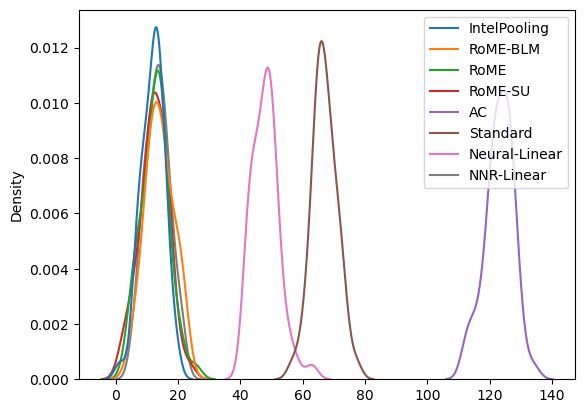

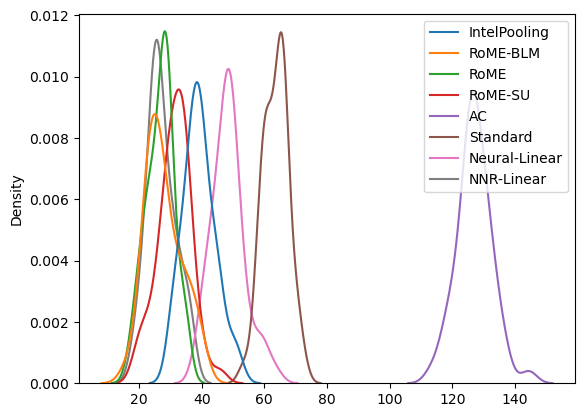

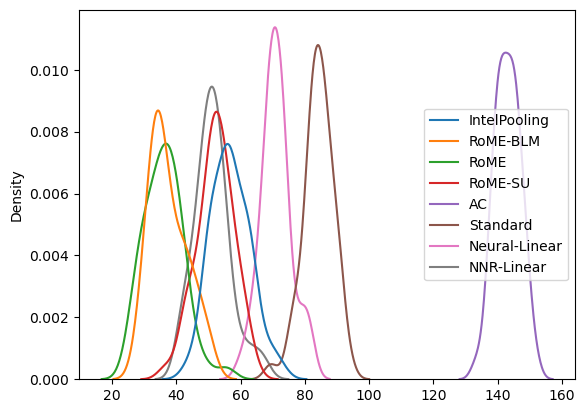

In [40]:
sns.kdeplot(data=final_homogeneous_regret_df)
plt.show()

sns.kdeplot(data=final_heterogeneous_regret_df)
plt.show()

sns.kdeplot(data=final_nonlinear_regret_df)
plt.show()